# F8 — Week 11 Performance Review

**Objective**: Review the optimisation performance of F8 across all 11 submission rounds and propose strategy for next submission.

**Function**: F8 (8D input, 1D output, maximisation)

**Week 10 Strategy**: SFGP Matérn-2.5 ARD + Standardize(m=1) + qLogNEI + 512 MC samples + 8192 raw samples + ≥30 MLL restarts.

F8 is the highest-dimensional function (8D) with 40 initial samples. This notebook loads the Week 11 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 8
N_DIMS = 8
N_INITIAL = 40
WEEK = 11
USE_LOG_SCALE = False
DATA_DIR = '../../data/f8/'

## Step 1 — Load Data

In [22]:
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F8 — Week 11 Data Summary
  Input dimensions:  8
  Total samples:     51
  Initial samples:   40
  Submissions:       11
  Input shape:       (51, 8)
  Output shape:      (51,)
  Best output:       9.98247
  Worst output:      5.59219

Sample | x1 | x2 | x3 | x4 | x5 | x6 | x7 | x8 | y
-------------------------------------------------------------------------------------------------------------------------
   1(init) | 0.604994 | 0.292215 | 0.908453 | 0.355506 | 0.201669 | 0.575338 | 0.310311 | 0.734281 | 7.39872
   2(init) | 0.178007 | 0.566223 | 0.994862 | 0.210325 | 0.320153 | 0.707909 | 0.635384 | 0.107132 | 7.00523
   3(init) | 0.009077 | 0.811626 | 0.520520 | 0.075687 | 0.265112 | 0.091652 | 0.592415 | 0.367320 | 8.45948
   4(init) | 0.506028 | 0.653730 | 0.363411 | 0.177981 | 0.093728 | 0.197425 | 0.755827 | 0.292472 | 8.28401
   5(init) | 0.359909 | 0.249076 | 0.495997 | 0.709215 | 0.114987 | 0.289207 | 0.557295 | 0.593882 | 8.60612
   6(init) | 0.778818 | 0.003419 | 0.337983 | 

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

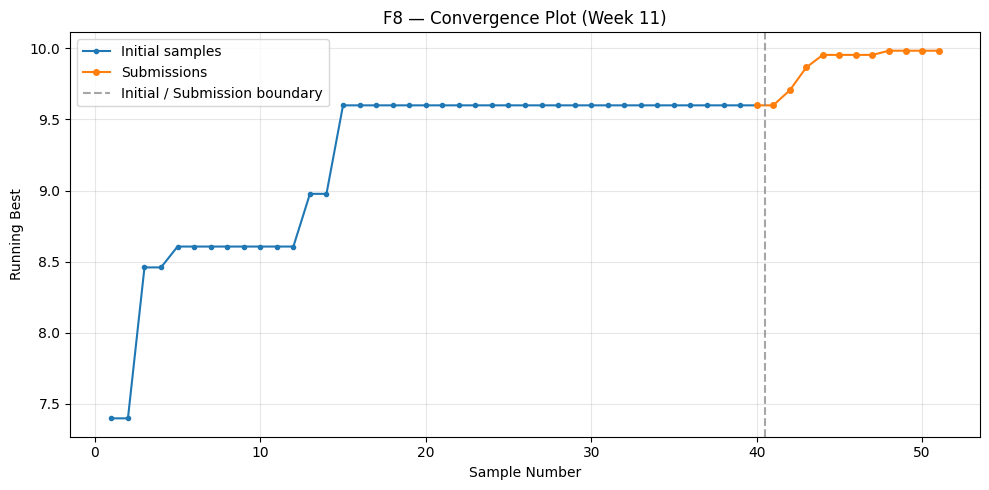

In [23]:
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))
x_all = np.arange(1, n_total + 1)

ax.plot(x_all[:N_INITIAL], running_best[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=3)
ax.plot(x_all[N_INITIAL-1:], running_best[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=4)
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_ylabel('Running Best')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. With 8 dimensions there are 28 pairs — showing all for completeness. Initial samples in **blue**, submission samples in **orange** (numbered by week).

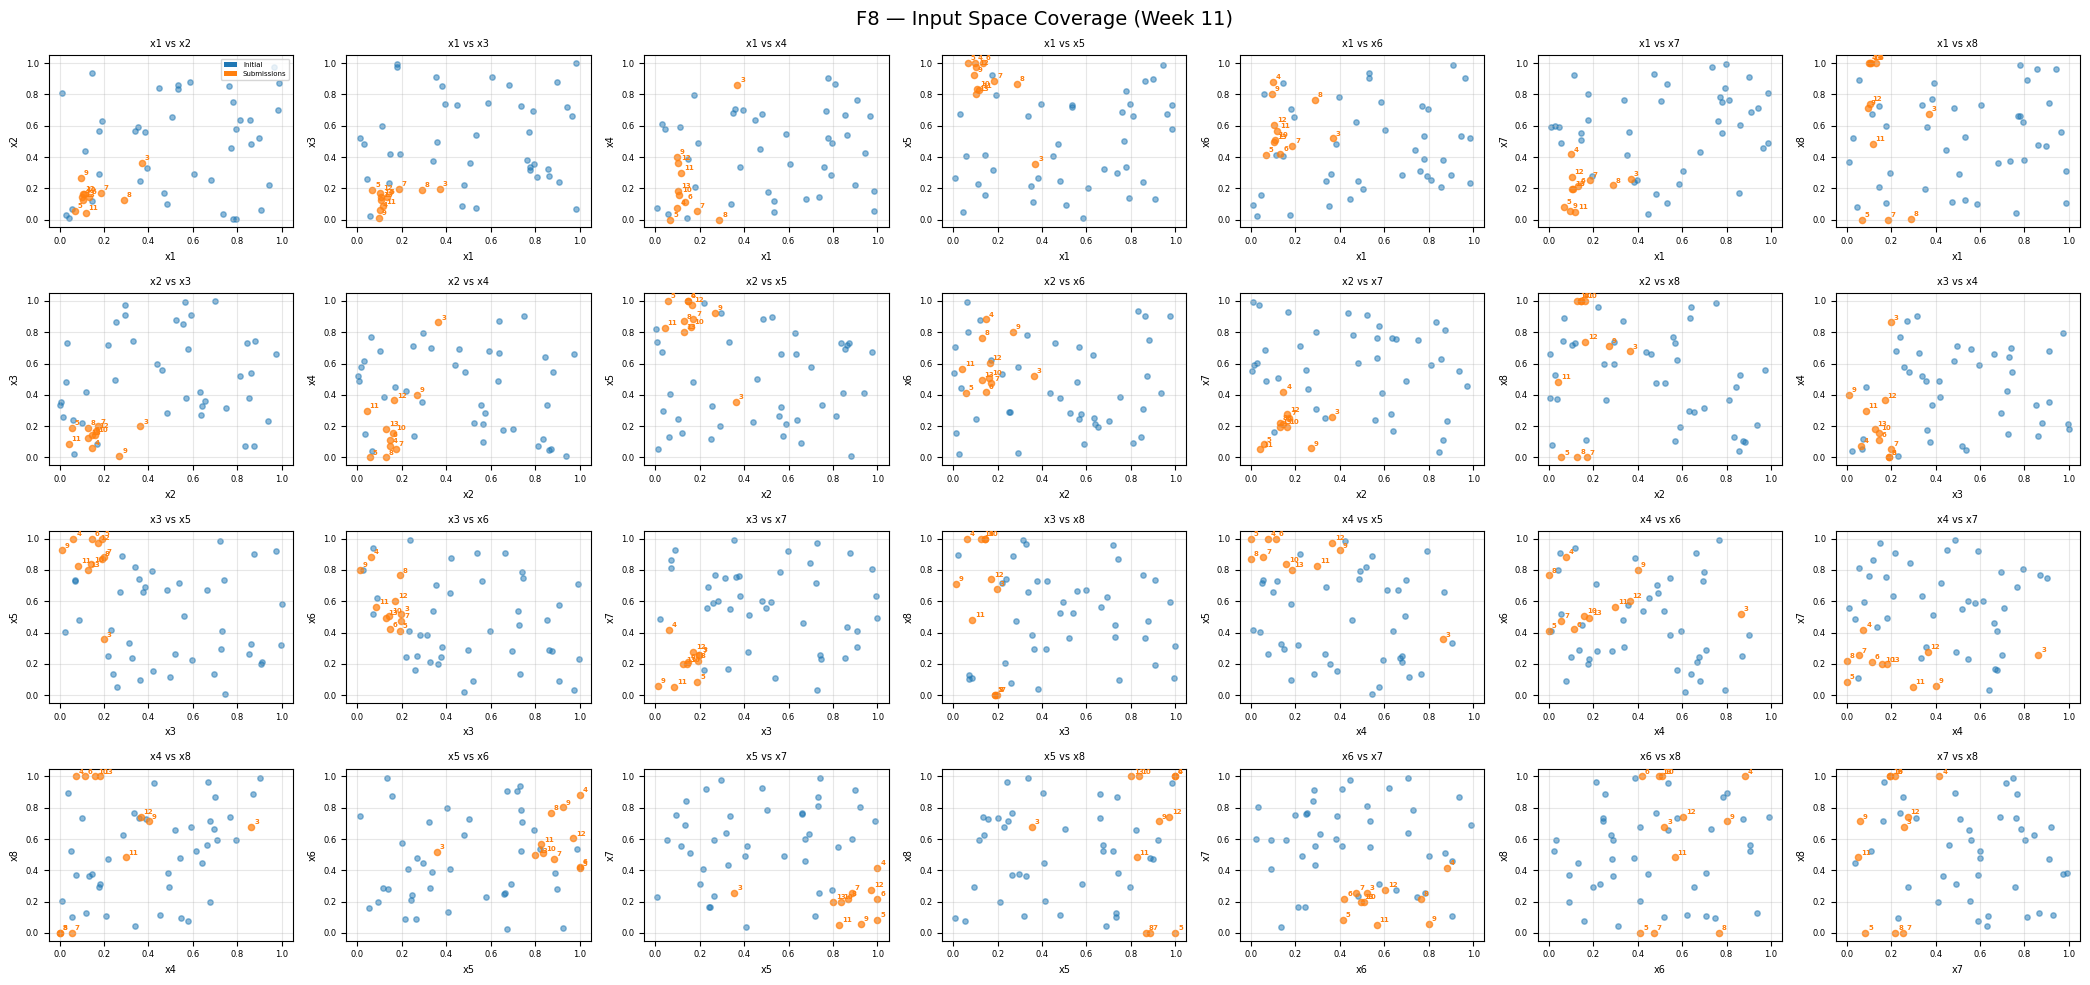

In [24]:
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

n_cols = 7
n_rows = math.ceil(n_pairs / n_cols)
fig_width = n_cols * 3
fig_height = n_rows * 2.5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                         squeeze=False)

for idx, (di, dj) in enumerate(pairs):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
               c='tab:blue', marker='o', s=15, alpha=0.5, label='Initial')

    for k in range(N_INITIAL, n_total):
        week_num = k - N_INITIAL + 3
        ax.scatter(inputs[k, di], inputs[k, dj],
                   c='tab:orange', marker='o', s=20, alpha=0.7)
        ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                    textcoords='offset points', xytext=(2, 2),
                    fontsize=5, color='tab:orange', fontweight='bold')

    ax.set_xlabel(f'x{di+1}', fontsize=7)
    ax.set_ylabel(f'x{dj+1}', fontsize=7)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'x{di+1} vs x{dj+1}', fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=6)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                   Patch(facecolor='tab:orange', label='Submissions')]
axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=5)

for idx in range(n_pairs, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
fig.tight_layout()
plt.show()

## Step 4 — Performance Evaluation

### Week 10 Strategy

- **Surrogate**: SFGP Matérn-2.5 ARD + Standardize(m=1)
- **Acquisition**: qLogNEI + 512 MC samples + 8192 raw samples + ≥30 MLL restarts
- **Key features**: High raw_samples and MC samples to handle 8D space; distance-based selection for diversity
- **Status**: 4/10 improvements — borderline stalling

### Performance Summary

In [25]:
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     9.59848
Best value (final):       9.98247
Improvements:             4/11
Max consecutive no-improve: 3
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |        9.18047 |        9.59848 | ✗
   4 |        9.70407 |        9.70407 | ✓
   5 |        9.86504 |        9.86504 | ✓
   6 |        9.95303 |        9.95303 | ✓
   7 |        9.91584 |        9.95303 | ✗
   8 |        9.78629 |        9.95303 | ✗
   9 |        9.73921 |        9.95303 | ✗
  10 |        9.98247 |        9.98247 | ✓
  11 |        9.90953 |        9.98247 | ✗
  12 |        9.90994 |        9.98247 | ✗
  13 |         9.9824 |        9.98247 | ✗


## Step 5 — Strategy Proposals for Next Submission

Review the performance metrics and convergence plot above. Key considerations for F8:

1. **F8 is the highest-dimensional function (8D)** with 40 initial + 9 submitted = 49 total samples. The 8D space is severely undersampled relative to its volume.

2. **If week 11 improved**: The SFGP Matérn-2.5 ARD approach is still finding improvements. Continue with:
   - Same surrogate and acquisition configuration
   - Increase raw_samples from 8192 to 12000 for better coverage of the 8D space
   - Consider increasing MC samples from 512 to 1024 for more accurate acquisition estimates
   - Increase MLL restarts to 50 — with 50+ data points, the likelihood surface has more structure

3. **If week 11 did NOT improve**: 8D needs aggressive exploration:
   - **ARD lengthscale analysis is critical** — with 8 dimensions, some may be irrelevant. Remove or fix dimensions with very large lengthscales to reduce effective dimensionality
   - **Increase raw_samples to 16384** — the 8D space is vast and needs extensive sampling
   - **Try TuRBO (Trust Region BO)** — local optimisation within an adaptive trust region is well-suited for high-D problems
   - **Switch to NN surrogate** (like F7) — GPs scale poorly to 8D; an NN with ensemble for uncertainty may work better
   - **Thompson Sampling** with random Fourier features — efficient exploration in high dimensions

4. **General**: F8 had 4/10 improvements but was listed as borderline stalling. The 8D search space is the key challenge. With ~50 data points in 8D, the GP sees an extremely sparse landscape. Dimensionality reduction (via ARD or PCA) could be the most impactful single change.

## ARD Feature Relevance Analysis

Automatic Relevance Determination (ARD) assigns a separate lengthscale parameter to each input dimension in the GP kernel. **Smaller lengthscale → the model is more sensitive to that dimension → higher relevance.**

Below we fit a SingleTaskGP with a Matérn-2.5 ARD kernel on the current data, extract the per-dimension lengthscales, and visualise the normalised relevance scores. The output transform matches the optimisation notebook: Standardize(m=1).

In [26]:
import torch
import gpytorch
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.priors import GammaPrior
from gpytorch.constraints import GreaterThan

# Prepare training data
X_train = torch.tensor(inputs, dtype=torch.float64)
Y_train = torch.tensor(outputs, dtype=torch.float64).unsqueeze(-1)

# Fit SingleTaskGP with Matérn-2.5 ARD kernel
covar_module = ScaleKernel(
    MaternKernel(nu=2.5, ard_num_dims=N_DIMS, lengthscale_prior=GammaPrior(3.0, 6.0)),
    outputscale_prior=GammaPrior(2.0, 0.15),
)
model = SingleTaskGP(X_train, Y_train, covar_module=covar_module, outcome_transform=Standardize(m=1))
model.likelihood.noise_covar.register_constraint("raw_noise", GreaterThan(1e-7))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

# Extract ARD lengthscales
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
dim_names = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]

print(f"F{FUNC_NUM}: ARD Lengthscales (Matérn-2.5 kernel)")
print(f"{'Dimension':<15} {'Lengthscale':>12}")
print("-" * 28)
for name, ls in zip(dim_names, lengthscales):
    print(f"{name:<15} {ls:>12.6f}")

F8: ARD Lengthscales (Matérn-2.5 kernel)
Dimension        Lengthscale
----------------------------
x1                  0.751850
x2                  1.075933
x3                  0.598471
x4                  1.141101
x5                  1.352660
x6                  1.288728
x7                  0.834067
x8                  1.439685


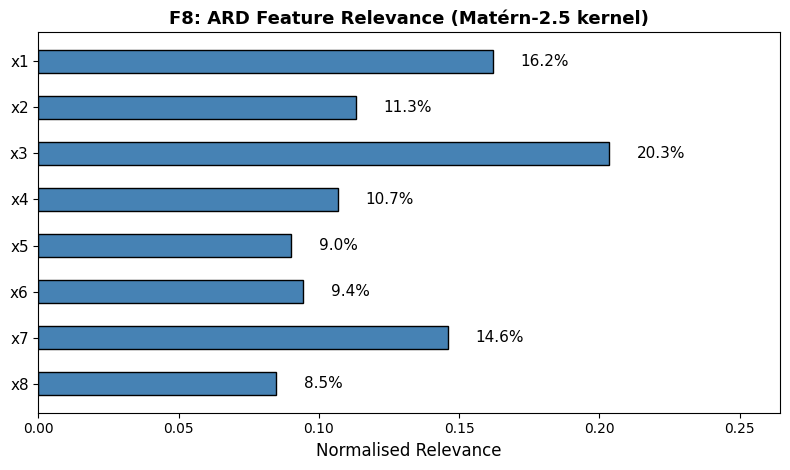

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Compute normalised relevance: relevance = 1/lengthscale, then normalise to sum to 1
inv_lengthscales = 1.0 / lengthscales
relevance = inv_lengthscales / inv_lengthscales.sum()

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(8, max(3, len(dim_names) * 0.6)))
y_pos = np.arange(len(dim_names))
bars = ax.barh(y_pos, relevance, color="steelblue", edgecolor="black", height=0.5)

# Annotate bars with percentage
for bar, rel in zip(bars, relevance):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{rel:.1%}", va="center", fontsize=11)

ax.set_yticks(y_pos)
ax.set_yticklabels(dim_names, fontsize=11)
ax.set_xlabel("Normalised Relevance", fontsize=12)
ax.set_title(f"F{FUNC_NUM}: ARD Feature Relevance (Matérn-2.5 kernel)", fontsize=13, fontweight="bold")
ax.set_xlim(0, min(1.0, relevance.max() * 1.3))
ax.invert_yaxis()
plt.tight_layout()
plt.show()